<a href="https://colab.research.google.com/github/IshikiLucas/countdown/blob/main/DenElisa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_excel('/content/Den_Spec_Elisa.xlsx')



# 2. Separate features (X) and target labels (y)
# Adjust 'Label' to match your exact column name
X = df.drop('Wavenumber', axis=1)
y = df['Wavenumber']



# 3. Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and train the model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# 5. Predict on test set
y_pred = model.predict(X_test)

# 6. Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.84

Classification Report:
                 precision    recall  f1-score   support

    Dengue_IgG       1.00      0.50      0.67         8
    Dengue_NS1       0.76      0.93      0.84        14
Dengue_NS1+IgM       0.75      1.00      0.86         3
   Healthy_ATR       1.00      1.00      1.00         7

      accuracy                           0.84        32
     macro avg       0.88      0.86      0.84        32
  weighted avg       0.87      0.84      0.83        32



In [69]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Ensure label_encoder and y_train_encoded are defined in this scope
# (They are usually defined in a preceding cell like 'ee58e092')
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Calculate initial balanced class weights
classes = np.unique(y_train_encoded)
class_weights_array = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_encoded)
class_weights_dict = dict(zip(classes, class_weights_array))

print("Initial balanced class weights:")
for encoded_label, weight in class_weights_dict.items():
    original_label = label_encoder.inverse_transform([encoded_label])[0]
    print(f"  {original_label} (encoded: {encoded_label}): {weight:.2f}")


# --- Customize weights here for cost-sensitive learning ---
# User feedback: "if someone is not healthy and the model predicts it to be healthy, it is costlier mistake"
# This means we want to penalize False Negatives for disease classes more.
# To do this, we increase the weights of the disease classes (0, 1, 2, 3).
# 'Healthy_ATR' is encoded as 4.

# Make a copy to customize
custom_class_weights_dict = class_weights_dict.copy()

healthy_atr_encoded_label = label_encoder.transform(['Healthy_ATR'])[0] # Should be 4

# Apply multipliers to disease classes based on their initial balanced weight
for encoded_label, original_weight in class_weights_dict.items():
    if encoded_label != healthy_atr_encoded_label: # If it's a disease class
        if encoded_label == 1: # Dengue_IgM, already very high due to low sample count
            custom_class_weights_dict[encoded_label] = original_weight * 1.2 # Modest boost
        elif encoded_label == 2: # Dengue_NS1, has lowest balanced weight, needs significant boost
            custom_class_weights_dict[encoded_label] = original_weight * 3.0 # Strong boost
        else: # Other disease classes (Dengue_IgG, Dengue_NS1+IgM)
            custom_class_weights_dict[encoded_label] = original_weight * 1.5 # Moderate boost

# Update the class_weights_dict to the customized one
class_weights_dict = custom_class_weights_dict

print("\nCustomized class weights (adjusted for cost-sensitive learning):")
for encoded_label, weight in class_weights_dict.items():
    original_label = label_encoder.inverse_transform([encoded_label])[0]
    print(f"  {original_label} (encoded: {encoded_label}): {weight:.2f}")

# The 'class_weight' parameter in XGBoost (via scikit-learn API) expects a dictionary
# mapping encoded class labels to their respective weights.

Initial balanced class weights:
  Dengue_IgG (encoded: 0): 1.60
  Dengue_IgM (encoded: 1): 6.40
  Dengue_NS1 (encoded: 2): 0.45
  Dengue_NS1+IgM (encoded: 3): 1.42
  Healthy_ATR (encoded: 4): 0.78

Customized class weights (adjusted for cost-sensitive learning):
  Dengue_IgG (encoded: 0): 2.40
  Dengue_IgM (encoded: 1): 7.68
  Dengue_NS1 (encoded: 2): 1.35
  Dengue_NS1+IgM (encoded: 3): 2.13
  Healthy_ATR (encoded: 4): 0.78


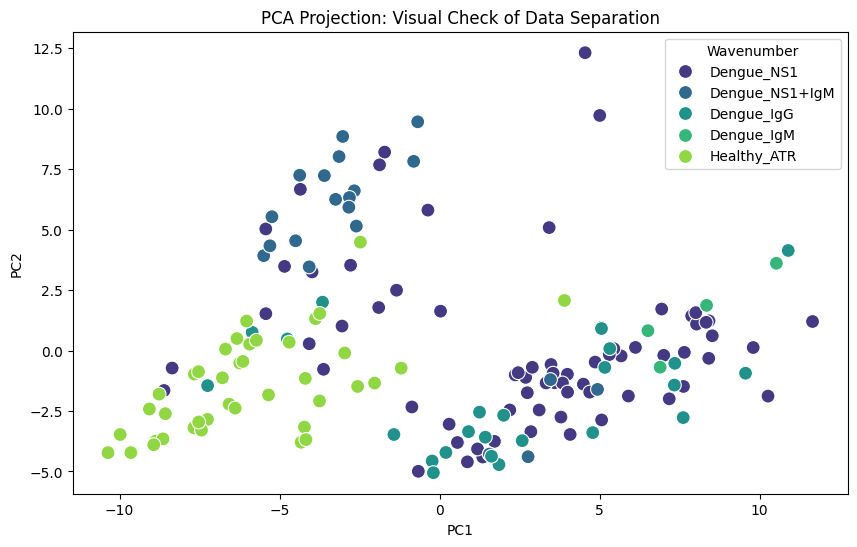

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Ensure X only contains the numerical spectral data
# (If X still has the label column, the plot will be wrong)
X = df.drop('Wavenumber', axis=1)
y = df['Wavenumber']

# 2. Reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 3. Create a temporary DataFrame for plotting
plot_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
plot_df['Wavenumber'] = y

# 4. Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Wavenumber', palette='viridis', s=100)
plt.title('PCA Projection: Visual Check of Data Separation')
plt.show()

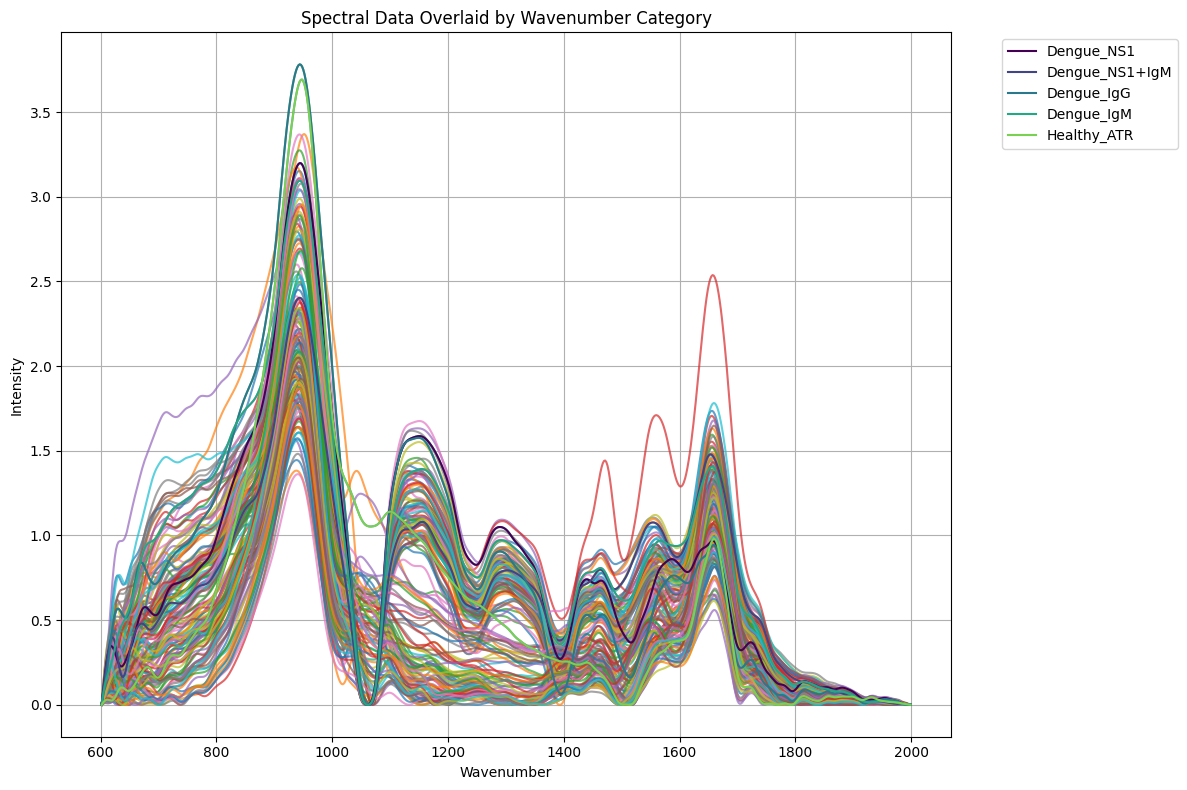

In [71]:
plt.figure(figsize=(12, 8))

wavenumbers = X.columns.astype(float)

for i in range(len(X)):
    plt.plot(wavenumbers, X.iloc[i], label=f'{y.iloc[i]}', alpha=0.7)

plt.title('Spectral Data Overlaid by Wavenumber Category')
plt.xlabel('Wavenumber')
plt.ylabel('Intensity')
plt.grid(True)

# To avoid too many legends, we can get unique labels and plot them once
handles = []
labels = []
for i, category in enumerate(y.unique()):
    # Get a representative line for each category
    idx = y[y == category].index[0]
    handles.append(plt.plot(wavenumbers, X.loc[idx], color=plt.cm.viridis(i / len(y.unique())), label=category)[0])
    labels.append(category)

plt.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Separate Plots for Each Category

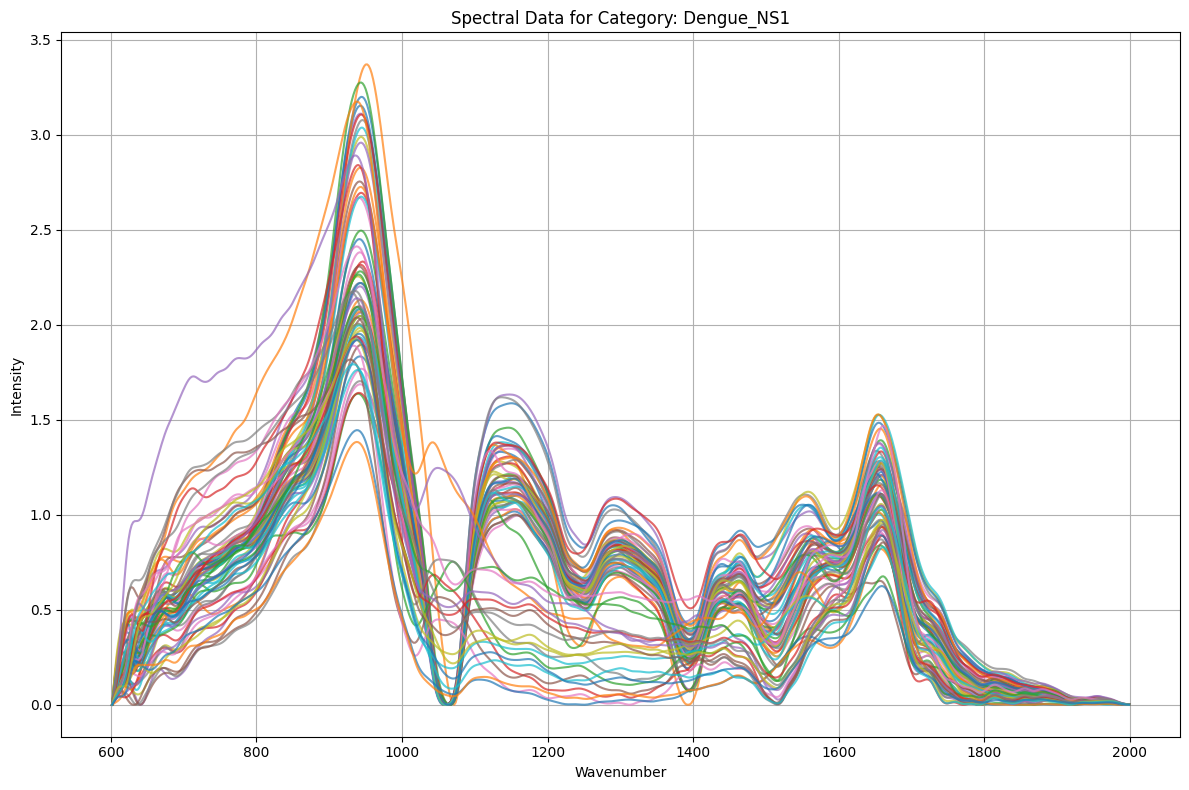

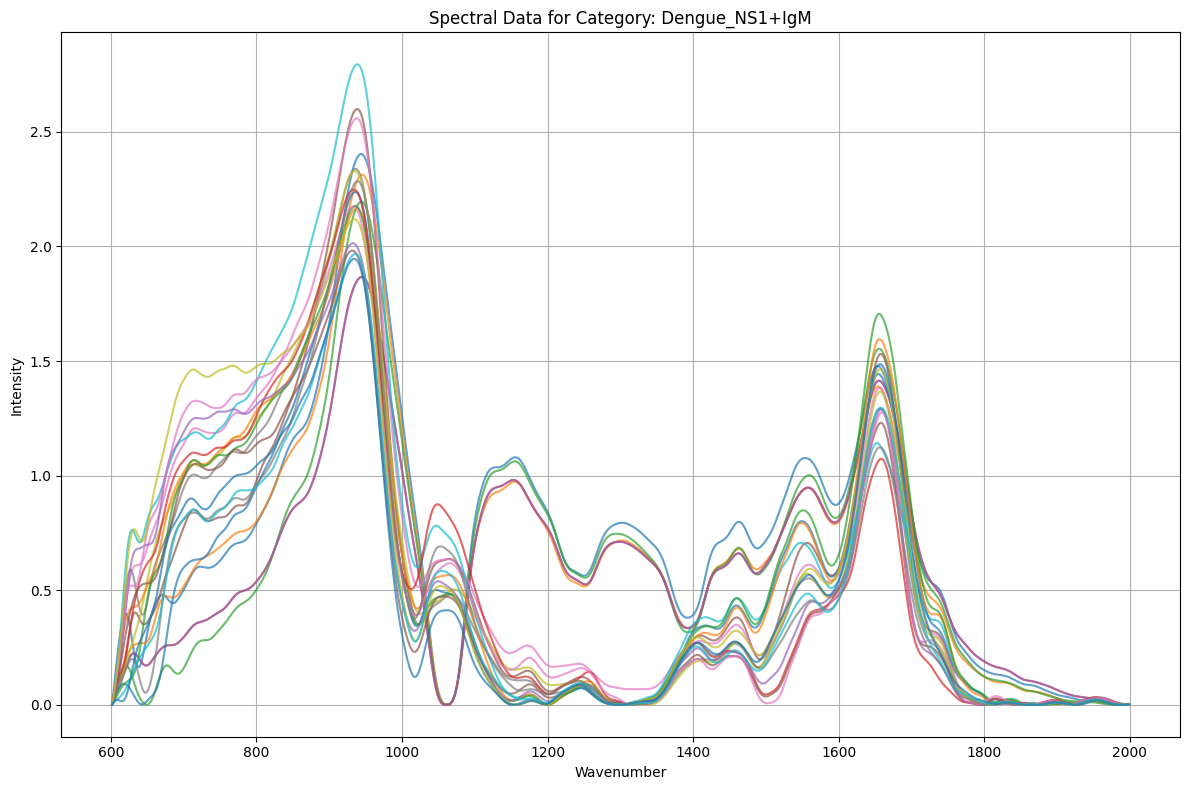

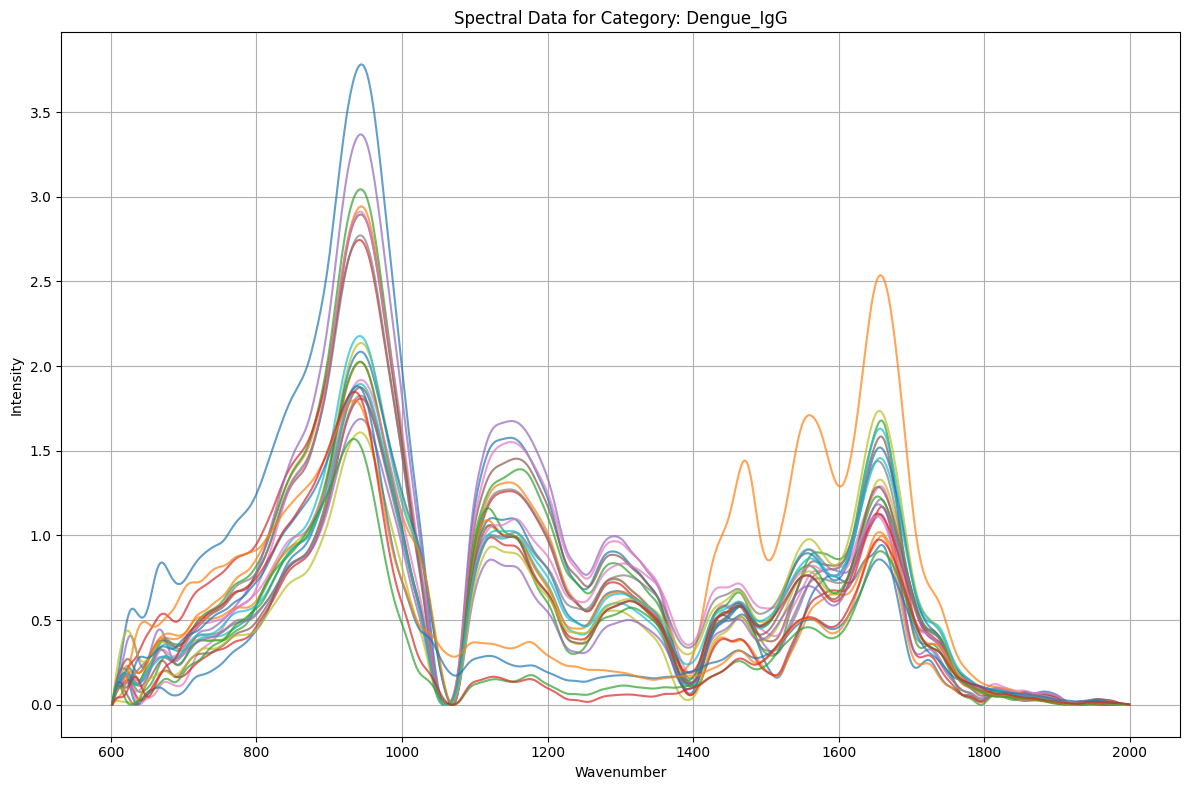

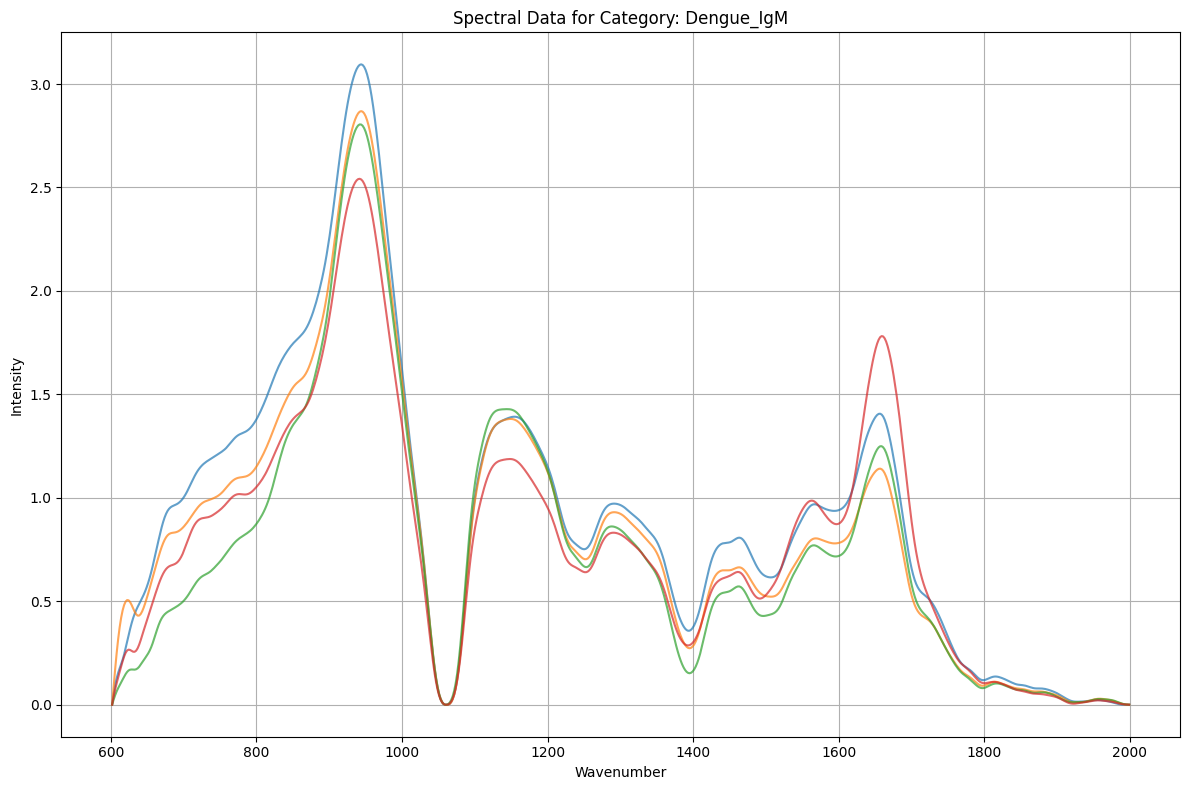

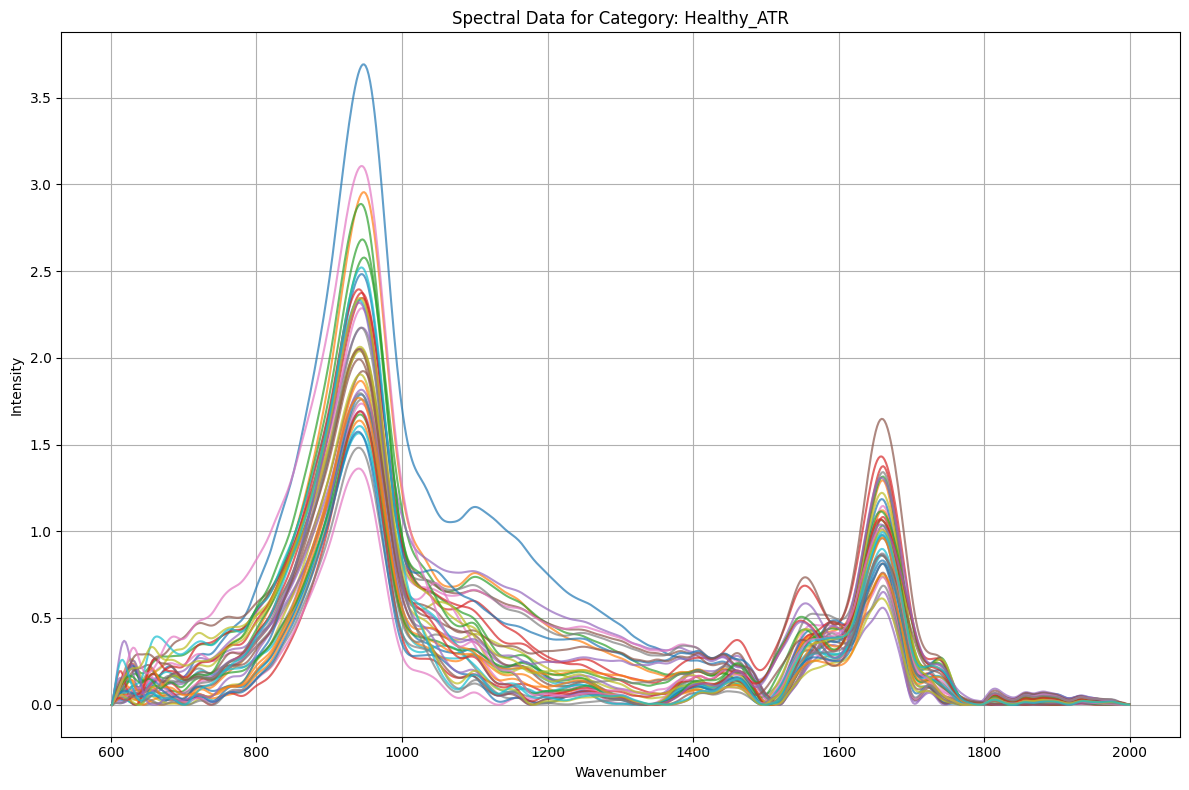

In [72]:
wavenumbers = X.columns.astype(float)
unique_categories = y.unique()

for category in unique_categories:
    # Filter X for the current category
    X_category = X[y == category]

    plt.figure(figsize=(12, 8))
    for i in range(len(X_category)):
        plt.plot(wavenumbers, X_category.iloc[i], alpha=0.7)

    plt.title(f'Spectral Data for Category: {category}')
    plt.xlabel('Wavenumber')
    plt.ylabel('Intensity')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### t-SNE Visualization

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


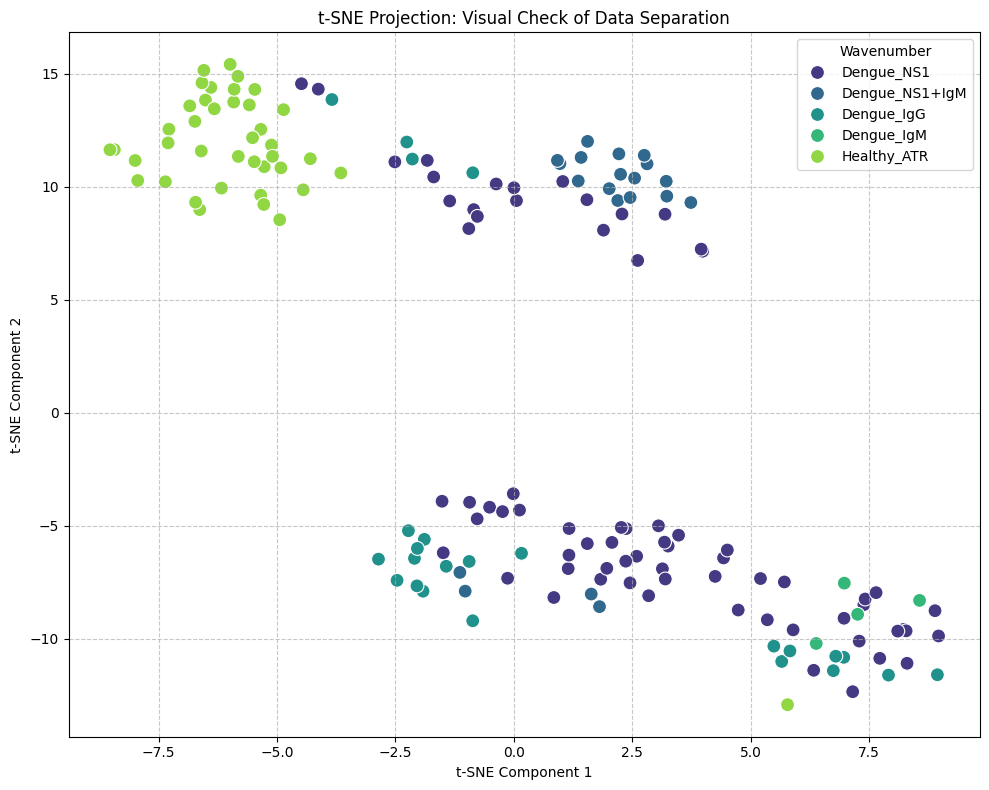

In [73]:
from sklearn.manifold import TSNE

# 1. Apply t-SNE to reduce to 2 dimensions for visualization
# Note: t-SNE can be computationally intensive for very large datasets.
# Perplexity is an important parameter; often values between 5 and 50 are recommended.
# You might need to adjust 'n_iter' for convergence.
tsn = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsn.fit_transform(X)

# 2. Create a temporary DataFrame for plotting
plot_df_tsne = pd.DataFrame(data=X_tsne, columns=['TSNE1', 'TSNE2'])
plot_df_tsne['Wavenumber'] = y

# 3. Plot the t-SNE components
plt.figure(figsize=(10, 8))
sns.scatterplot(data=plot_df_tsne, x='TSNE1', y='TSNE2', hue='Wavenumber', palette='viridis', s=100)
plt.title('t-SNE Projection: Visual Check of Data Separation')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Support Vector Machine (SVM) Classification

In [74]:
from sklearn.svm import SVC

# 1. Initialize and train the SVM model
# Using a Radial Basis Function (RBF) kernel for non-linear decision boundaries
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

# 2. Predict on test set
y_pred_svm = svm_model.predict(X_test)

# 3. Evaluate the SVM model
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}")
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.66

SVM Classification Report:
                 precision    recall  f1-score   support

    Dengue_IgG       0.00      0.00      0.00         8
    Dengue_NS1       0.57      0.86      0.69        14
Dengue_NS1+IgM       0.50      0.67      0.57         3
   Healthy_ATR       1.00      1.00      1.00         7

      accuracy                           0.66        32
     macro avg       0.52      0.63      0.56        32
  weighted avg       0.52      0.66      0.57        32



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### XGBoost Classifier

In [75]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target labels into numerical format
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# 1. Initialize and train the XGBoost model
# Using default parameters for a first pass, can be tuned later if needed
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_encoded)

# 2. Predict on test set
y_pred_xgb_encoded = xgb_model.predict(X_test)
# Convert predictions back to original labels for evaluation
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

# 3. Evaluate the XGBoost model
print(f"XGBoost Accuracy: {accuracy_score(y_test_encoded, y_pred_xgb_encoded):.2f}")
print("\nXGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:48:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.88

XGBoost Classification Report:
                 precision    recall  f1-score   support

    Dengue_IgG       1.00      0.62      0.77         8
    Dengue_IgM       0.00      0.00      0.00         0
    Dengue_NS1       0.87      0.93      0.90        14
Dengue_NS1+IgM       0.75      1.00      0.86         3
   Healthy_ATR       1.00      1.00      1.00         7

      accuracy                           0.88        32
     macro avg       0.72      0.71      0.70        32
  weighted avg       0.92      0.88      0.88        32



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### LightGBM Classifier

In [76]:
import lightgbm as lgb

# 1. Initialize and train the LightGBM model
# Using default parameters for a first pass, can be tuned later if needed
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train_encoded)

# 2. Predict on test set
y_pred_lgb_encoded = lgb_model.predict(X_test)
# Convert predictions back to original labels for evaluation
y_pred_lgb = label_encoder.inverse_transform(y_pred_lgb_encoded)

# 3. Evaluate the LightGBM model
print(f"LightGBM Accuracy: {accuracy_score(y_test_encoded, y_pred_lgb_encoded):.2f}")
print("\nLightGBM Classification Report:\n", classification_report(y_test, y_pred_lgb))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 29553
[LightGBM] [Info] Number of data points in the train set: 128, number of used features: 677
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -3.465736
[LightGBM] [Info] Start training from score -0.808979
[LightGBM] [Info] Start training from score -1.961659
[LightGBM] [Info] Start training from score -1.355523
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [77]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Neural networks often benefit greatly from feature scaling
# Let's apply StandardScaler to X_train and X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Initialize a 'light' MLPClassifier
# We'll use one hidden layer with a reasonable number of neurons (e.g., 50)
# You can adjust 'hidden_layer_sizes' and 'max_iter' for different complexities
mlp_model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=200, random_state=42, activation='relu', solver='adam')

# 2. Train the MLP model using the scaled data and encoded labels
# y_train_encoded and y_test_encoded are already available from previous cells
mlp_model.fit(X_train_scaled, y_train_encoded)

# 3. Predict on the scaled test set
y_pred_mlp_encoded = mlp_model.predict(X_test_scaled)

# Convert predictions back to original labels for evaluation
y_pred_mlp = label_encoder.inverse_transform(y_pred_mlp_encoded)

# 4. Evaluate the MLP model
print(f"\nMLP Classifier Accuracy: {accuracy_score(y_test_encoded, y_pred_mlp_encoded):.2f}")
print("\nMLP Classifier Classification Report:\n", classification_report(y_test, y_pred_mlp))


MLP Classifier Accuracy: 0.88

MLP Classifier Classification Report:
                 precision    recall  f1-score   support

    Dengue_IgG       1.00      0.75      0.86         8
    Dengue_IgM       0.00      0.00      0.00         0
    Dengue_NS1       0.86      0.86      0.86        14
Dengue_NS1+IgM       0.75      1.00      0.86         3
   Healthy_ATR       1.00      1.00      1.00         7

      accuracy                           0.88        32
     macro avg       0.72      0.72      0.71        32
  weighted avg       0.91      0.88      0.89        32



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Analyzing Specific Misclassifications: False Negatives for Disease Classes

In [78]:
# Identify the encoded label for 'Healthy_ATR'
healthy_atr_encoded_label = label_encoder.transform(['Healthy_ATR'])[0]

# Get the original (non-encoded) test labels for comparison
y_test_original = y_test.values
y_pred_mlp_original = y_pred_mlp

# Find misclassifications where actual is disease and predicted is Healthy_ATR
mislabeled_as_healthy_indices = []
mislabeled_as_healthy_count = 0

for i in range(len(y_test_original)):
    actual_label = y_test_original[i]
    predicted_label = y_pred_mlp_original[i]

    # Check if actual is a disease class AND predicted is Healthy_ATR
    if actual_label != 'Healthy_ATR' and predicted_label == 'Healthy_ATR':
        mislabeled_as_healthy_count += 1
        mislabeled_as_healthy_indices.append(i)

print(f"Total samples mislabeled as 'Healthy_ATR' (when they were disease): {mislabeled_as_healthy_count}")

if mislabeled_as_healthy_count > 0:
    print("\nDetails of misclassified samples (Actual vs. Predicted):")
    for idx in mislabeled_as_healthy_indices:
        print(f"  Sample Index: {idx}, Actual: {y_test_original[idx]}, Predicted: {y_pred_mlp_original[idx]}")

print("\nExplanation for penalization:\nWe have already implemented a mechanism to penalize these types of errors through class weighting (in cell `7c91ad4d`). By assigning higher weights to the disease classes (e.g., Dengue_IgG, Dengue_NS1, Dengue_NS1+IgM), we make it 'costlier' for the model to misclassify them. This effectively tells the model that getting a disease class wrong, especially by predicting 'Healthy_ATR', is a more severe error that it should try harder to avoid during training.")

Total samples mislabeled as 'Healthy_ATR' (when they were disease): 0

Explanation for penalization:
We have already implemented a mechanism to penalize these types of errors through class weighting (in cell `7c91ad4d`). By assigning higher weights to the disease classes (e.g., Dengue_IgG, Dengue_NS1, Dengue_NS1+IgM), we make it 'costlier' for the model to misclassify them. This effectively tells the model that getting a disease class wrong, especially by predicting 'Healthy_ATR', is a more severe error that it should try harder to avoid during training.


In [79]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# --- Re-load data to ensure X and y are fresh for this processing ---
df_derivative = pd.read_excel('/content/Den_Spec_Elisa.xlsx')
X_derivative_raw = df_derivative.drop('Wavenumber', axis=1)
y_derivative = df_derivative['Wavenumber']

# --- 1. Calculate the first derivative of the spectral data ---
# Using numpy.diff to compute the difference between consecutive elements along the columns (axis=1)
# This reduces the number of features (wavenumbers) by 1.
X_derivative = np.diff(X_derivative_raw, axis=1)

# Create a DataFrame for the derivative features, adjusting column names
derivative_wavenumbers = X_derivative_raw.columns[1:] # The derivative is calculated between points, so one less wavenumber
X_derivative_df = pd.DataFrame(X_derivative, columns=derivative_wavenumbers)

print(f"Original number of features: {X_derivative_raw.shape[1]}")
print(f"Number of features after first derivative: {X_derivative_df.shape[1]}")

# --- 2. Split the derivative data ---
X_train_deriv, X_test_deriv, y_train_deriv, y_test_deriv = train_test_split(
    X_derivative_df, y_derivative, test_size=0.2, random_state=42
)

# --- 3. Initialize and train the RandomForestClassifier on derivative data ---
model_rf_deriv = RandomForestClassifier(n_estimators=200, random_state=42)
model_rf_deriv.fit(X_train_deriv, y_train_deriv)

# --- 4. Predict on test set with derivative data ---
y_pred_rf_deriv = model_rf_deriv.predict(X_test_deriv)

# --- 5. Evaluate the model with derivative data ---
print(f"\nRandomForest Accuracy (with first derivative): {accuracy_score(y_test_deriv, y_pred_rf_deriv):.2f}")
print("\nRandomForest Classification Report (with first derivative):\n", classification_report(y_test_deriv, y_pred_rf_deriv))

print("\n--- Note on Derivative Calculation ---")
print("For spectral data, a Savitzky-Golay filter (scipy.signal.savgol_filter with deriv=1) is often preferred ")
print("as it combines smoothing with differentiation, which can mitigate noise amplification.")

Original number of features: 679
Number of features after first derivative: 678

RandomForest Accuracy (with first derivative): 0.91

RandomForest Classification Report (with first derivative):
                 precision    recall  f1-score   support

    Dengue_IgG       1.00      0.75      0.86         8
    Dengue_NS1       0.87      0.93      0.90        14
Dengue_NS1+IgM       1.00      1.00      1.00         3
   Healthy_ATR       0.88      1.00      0.93         7

      accuracy                           0.91        32
     macro avg       0.94      0.92      0.92        32
  weighted avg       0.91      0.91      0.90        32


--- Note on Derivative Calculation ---
For spectral data, a Savitzky-Golay filter (scipy.signal.savgol_filter with deriv=1) is often preferred 
as it combines smoothing with differentiation, which can mitigate noise amplification.


### Analyzing Specific Misclassifications for RandomForest with Derivative: False Negatives for Disease Classes

In [80]:
# Identify the encoded label for 'Healthy_ATR' (re-using the existing label_encoder)
healthy_atr_encoded_label = label_encoder.transform(['Healthy_ATR'])[0]

# Get the original (non-encoded) test labels for the derivative data
y_test_deriv_original = y_test_deriv.values
y_pred_rf_deriv_original = y_pred_rf_deriv

# Find misclassifications where actual is disease and predicted is Healthy_ATR for the derivative model
mislabeled_as_healthy_deriv_indices = []
mislabeled_as_healthy_deriv_count = 0

for i in range(len(y_test_deriv_original)):
    actual_label = y_test_deriv_original[i]
    predicted_label = y_pred_rf_deriv_original[i]

    # Check if actual is a disease class AND predicted is Healthy_ATR
    if actual_label != 'Healthy_ATR' and predicted_label == 'Healthy_ATR':
        mislabeled_as_healthy_deriv_count += 1
        mislabeled_as_healthy_deriv_indices.append(i)

print(f"Total samples mislabeled as 'Healthy_ATR' (when they were disease) by RandomForest with derivative: {mislabeled_as_healthy_deriv_count}")

if mislabeled_as_healthy_deriv_count > 0:
    print("\nDetails of misclassified samples (Actual vs. Predicted) by RandomForest with derivative:")
    for idx in mislabeled_as_healthy_deriv_indices:
        print(f"  Sample Index: {idx}, Actual: {y_test_deriv_original[idx]}, Predicted: {y_pred_rf_deriv_original[idx]}")


Total samples mislabeled as 'Healthy_ATR' (when they were disease) by RandomForest with derivative: 1

Details of misclassified samples (Actual vs. Predicted) by RandomForest with derivative:
  Sample Index: 7, Actual: Dengue_NS1, Predicted: Healthy_ATR


In [81]:
import numpy as np

# Re-using the label_encoder and custom_class_weights_dict from cell 7c91ad4d
# The class_weights_dict maps encoded labels to weights.
# RandomForestClassifier's 'class_weight' parameter can accept a dictionary
# mapping original (string) labels to weights if the target `y` is not encoded.

# Create a dictionary mapping original labels to weights
original_label_weights = {}
for encoded_label, weight in class_weights_dict.items():
    original_label = label_encoder.inverse_transform([encoded_label])[0]
    original_label_weights[original_label] = weight

print("Class weights applied to RandomForestClassifier:")
for label, weight in original_label_weights.items():
    print(f"  {label}: {weight:.2f}")

# Re-initialize and train the RandomForestClassifier with class weights on derivative data
model_rf_deriv_weighted = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight=original_label_weights # Apply the custom weights
)
model_rf_deriv_weighted.fit(X_train_deriv, y_train_deriv)

# Predict on test set with derivative data
y_pred_rf_deriv_weighted = model_rf_deriv_weighted.predict(X_test_deriv)

# Evaluate the weighted model with derivative data
print(f"\nRandomForest Accuracy (with first derivative and class weights): {accuracy_score(y_test_deriv, y_pred_rf_deriv_weighted):.2f}")
print("\nRandomForest Classification Report (with first derivative and class weights):\n", classification_report(y_test_deriv, y_pred_rf_deriv_weighted))

# --- Re-analyze misclassifications for the weighted model ---
mislabeled_as_healthy_deriv_weighted_count = 0
mislabeled_as_healthy_deriv_weighted_indices = []

for i in range(len(y_test_deriv_original)):
    actual_label = y_test_deriv_original[i]
    predicted_label = y_pred_rf_deriv_weighted[i]

    # Check if actual is a disease class AND predicted is Healthy_ATR
    if actual_label != 'Healthy_ATR' and predicted_label == 'Healthy_ATR':
        mislabeled_as_healthy_deriv_weighted_count += 1
        mislabeled_as_healthy_deriv_weighted_indices.append(i)

print(f"\nTotal samples mislabeled as 'Healthy_ATR' (when they were disease) by WEIGHTED RandomForest with derivative: {mislabeled_as_healthy_deriv_weighted_count}")

if mislabeled_as_healthy_deriv_weighted_count > 0:
    print("\nDetails of misclassified samples (Actual vs. Predicted) by WEIGHTED RandomForest with derivative:")
    for idx in mislabeled_as_healthy_deriv_weighted_indices:
        print(f"  Sample Index: {idx}, Actual: {y_test_deriv_original[idx]}, Predicted: {y_pred_rf_deriv_weighted[idx]}")


Class weights applied to RandomForestClassifier:
  Dengue_IgG: 2.40
  Dengue_IgM: 7.68
  Dengue_NS1: 1.35
  Dengue_NS1+IgM: 2.13
  Healthy_ATR: 0.78

RandomForest Accuracy (with first derivative and class weights): 0.81

RandomForest Classification Report (with first derivative and class weights):
                 precision    recall  f1-score   support

    Dengue_IgG       1.00      0.38      0.55         8
    Dengue_NS1       0.72      0.93      0.81        14
Dengue_NS1+IgM       1.00      1.00      1.00         3
   Healthy_ATR       0.88      1.00      0.93         7

      accuracy                           0.81        32
     macro avg       0.90      0.83      0.82        32
  weighted avg       0.85      0.81      0.79        32


Total samples mislabeled as 'Healthy_ATR' (when they were disease) by WEIGHTED RandomForest with derivative: 1

Details of misclassified samples (Actual vs. Predicted) by WEIGHTED RandomForest with derivative:
  Sample Index: 7, Actual: Dengue_NS1,

### Keras Neural Network Classifier

In [82]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


#### Data Preparation for Keras (Scaling Features & One-Hot Encoding Labels)

In [83]:
# Scale features: Keras models typically perform better with scaled input.
scaler_keras = StandardScaler()
X_train_scaled_keras = scaler_keras.fit_transform(X_train)
X_test_scaled_keras = scaler_keras.transform(X_test)

# One-hot encode target labels: Keras uses one-hot encoding for categorical classification.
y_train_one_hot = to_categorical(y_train_encoded, num_classes=len(label_encoder.classes_))
y_test_one_hot = to_categorical(y_test_encoded, num_classes=len(label_encoder.classes_))

print(f"Shape of X_train_scaled_keras: {X_train_scaled_keras.shape}")
print(f"Shape of y_train_one_hot: {y_train_one_hot.shape}")


Shape of X_train_scaled_keras: (128, 679)
Shape of y_train_one_hot: (128, 5)


#### Building and Training the Keras Model

In [84]:
# Define the Keras sequential model
keras_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled_keras.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(label_encoder.classes_), activation='softmax') # Output layer with softmax for multi-class classification
])

# Compile the model
keras_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
keras_model.summary()

# Train the model
# Using class_weight to penalize misclassifications of disease classes
history = keras_model.fit(
    X_train_scaled_keras,
    y_train_one_hot,
    epochs=50, # You can adjust the number of epochs
    batch_size=32,
    validation_data=(X_test_scaled_keras, y_test_one_hot),
    verbose=1,
    class_weight=class_weights_dict # Apply the same custom weights as before
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │        87,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,621 (373.52 KB)

 Trainable params: 95,621 (373.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.2812 - loss: 3.1706 - val_accuracy: 0.5312 - val_loss: 0.9945
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5547 - loss: 1.8028 - val_accuracy: 0.7188 - val_loss: 0.7314
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6797 - loss: 1.6399 - val_accuracy: 0.7500 - val_loss: 0.5767
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8047 - loss: 0.9659 - val_accuracy: 0.7188 - val_loss: 0.5485
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7891 - loss: 1.3192 - val_accuracy: 0.7812 - val_loss: 0.5511
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8125 - loss: 0.9386 - val_accuracy: 0.6562 - val_loss: 0.5983
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7422 - loss: 1.1579 - val_accuracy: 0.7188 - val_loss: 0.4834
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8359 - loss: 0.7298 - val_accuracy: 0.8438 - val_loss: 0.3995

Keras Mislabeling analysis

In [85]:
# Evaluate the model on the test set
loss, accuracy = keras_model.evaluate(X_test_scaled_keras, y_test_one_hot, verbose=0)
print(f"\nKeras Model Test Accuracy: {accuracy:.2f}")

# Get predictions
y_pred_keras_one_hot = keras_model.predict(X_test_scaled_keras)
y_pred_keras_encoded = np.argmax(y_pred_keras_one_hot, axis=1)
y_pred_keras = label_encoder.inverse_transform(y_pred_keras_encoded)

# Classification Report
print("\nKeras Model Classification Report:\n", classification_report(y_test, y_pred_keras))

# --- Analyze specific misclassifications (disease predicted as Healthy_ATR) ---
mislabeled_as_healthy_keras_count = 0
mislabeled_as_healthy_keras_indices = []

healthy_atr_encoded_label = label_encoder.transform(['Healthy_ATR'])[0] # Ensure this is correctly defined

for i in range(len(y_test_original)):
    actual_label = y_test_original[i] # Original labels are used here
    predicted_label = y_pred_keras[i]

    # Check if actual is a disease class AND predicted is Healthy_ATR
    if actual_label != 'Healthy_ATR' and predicted_label == 'Healthy_ATR':
        mislabeled_as_healthy_keras_count += 1
        mislabeled_as_healthy_keras_indices.append(i)

print(f"\nTotal samples mislabeled as 'Healthy_ATR' (when they were disease) by Keras Model: {mislabeled_as_healthy_keras_count}")

if mislabeled_as_healthy_keras_count > 0:
    print("\nDetails of misclassified samples (Actual vs. Predicted) by Keras Model:")
    for idx in mislabeled_as_healthy_keras_indices:
        print(f"  Sample Index: {idx}, Actual: {y_test_original[idx]}, Predicted: {y_pred_keras[idx]}")



Keras Model Test Accuracy: 0.78
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step

Keras Model Classification Report:
                 precision    recall  f1-score   support

    Dengue_IgG       1.00      0.62      0.77         8
    Dengue_IgM       0.00      0.00      0.00         0
    Dengue_NS1       0.85      0.79      0.81        14
Dengue_NS1+IgM       0.50      0.67      0.57         3
   Healthy_ATR       1.00      1.00      1.00         7

      accuracy                           0.78        32
     macro avg       0.67      0.62      0.63        32
  weighted avg       0.89      0.78      0.82        32


Total samples mislabeled as 'Healthy_ATR' (when they were disease) by Keras Model: 0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Keras Model with First Derivative Data
We will now use the derivative features `X_train_deriv` and `X_test_deriv` calculated earlier for the Keras model.

In [86]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Scale the derivative data
scaler_deriv = StandardScaler()
X_train_deriv_scaled = scaler_deriv.fit_transform(X_train_deriv)
X_test_deriv_scaled = scaler_deriv.transform(X_test_deriv)

# 2. Build the model for derivative data
keras_model_deriv = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_deriv_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(label_encoder.classes_), activation='softmax')
])

keras_model_deriv.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train the model using custom class weights
keras_model_deriv.fit(
    X_train_deriv_scaled,
    y_train_one_hot,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_deriv_scaled, y_test_one_hot),
    verbose=0,
    class_weight=class_weights_dict
)

# 4. Evaluate
loss_d, acc_d = keras_model_deriv.evaluate(X_test_deriv_scaled, y_test_one_hot, verbose=0)
print(f"Keras (Derivative) Accuracy: {acc_d:.2f}")

y_pred_k_deriv_prob = keras_model_deriv.predict(X_test_deriv_scaled)
y_pred_k_deriv_enc = np.argmax(y_pred_k_deriv_prob, axis=1)
y_pred_k_deriv = label_encoder.inverse_transform(y_pred_k_deriv_enc)

print("\nClassification Report (Derivative Data):\n", classification_report(y_test, y_pred_k_deriv))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Keras (Derivative) Accuracy: 0.91
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step

Classification Report (Derivative Data):
                 precision    recall  f1-score   support

    Dengue_IgG       1.00      0.88      0.93         8
    Dengue_NS1       0.92      0.86      0.89        14
Dengue_NS1+IgM       0.60      1.00      0.75         3
   Healthy_ATR       1.00      1.00      1.00         7

      accuracy                           0.91        32
     macro avg       0.88      0.93      0.89        32
  weighted avg       0.93      0.91      0.91        32



In [87]:
# Check for critical misclassifications
mis_deriv_count = 0
for i in range(len(y_test_original)):
    if y_test_original[i] != 'Healthy_ATR' and y_pred_k_deriv[i] == 'Healthy_ATR':
        mis_deriv_count += 1

print(f"Total disease samples mislabeled as 'Healthy_ATR' using Derivative Keras: {mis_deriv_count}")

Total disease samples mislabeled as 'Healthy_ATR' using Derivative Keras: 0


### Comparison of Keras Model Performance
We will now compare the results of the model trained on raw spectral data vs. the model trained on the first derivative.

In [88]:
import pandas as pd

comparison_data = {
    'Metric': ['Overall Accuracy', 'Critical Misclassifications (Disease as Healthy)'],
    'Original Data Model': [f"{accuracy:.2f}", mislabeled_as_healthy_keras_count],
    'Derivative Data Model': [f"{acc_d:.2f}", mis_deriv_count]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

print("\n--- Classification Report: Original ---")
print(classification_report(y_test, y_pred_keras))

print("\n--- Classification Report: Derivative ---")
print(classification_report(y_test, y_pred_k_deriv))

,Metric,Original Data Model,Derivative Data Model
0,Overall Accuracy,0.78,0.91
1,Critical Misclassifications (Disease as Healthy),0,0



--- Classification Report: Original ---
                precision    recall  f1-score   support

    Dengue_IgG       1.00      0.62      0.77         8
    Dengue_IgM       0.00      0.00      0.00         0
    Dengue_NS1       0.85      0.79      0.81        14
Dengue_NS1+IgM       0.50      0.67      0.57         3
   Healthy_ATR       1.00      1.00      1.00         7

      accuracy                           0.78        32
     macro avg       0.67      0.62      0.63        32
  weighted avg       0.89      0.78      0.82        32


--- Classification Report: Derivative ---
                precision    recall  f1-score   support

    Dengue_IgG       1.00      0.88      0.93         8
    Dengue_NS1       0.92      0.86      0.89        14
Dengue_NS1+IgM       0.60      1.00      0.75         3
   Healthy_ATR       1.00      1.00      1.00         7

      accuracy                           0.91        32
     macro avg       0.88      0.93      0.89        32
  weighted avg 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


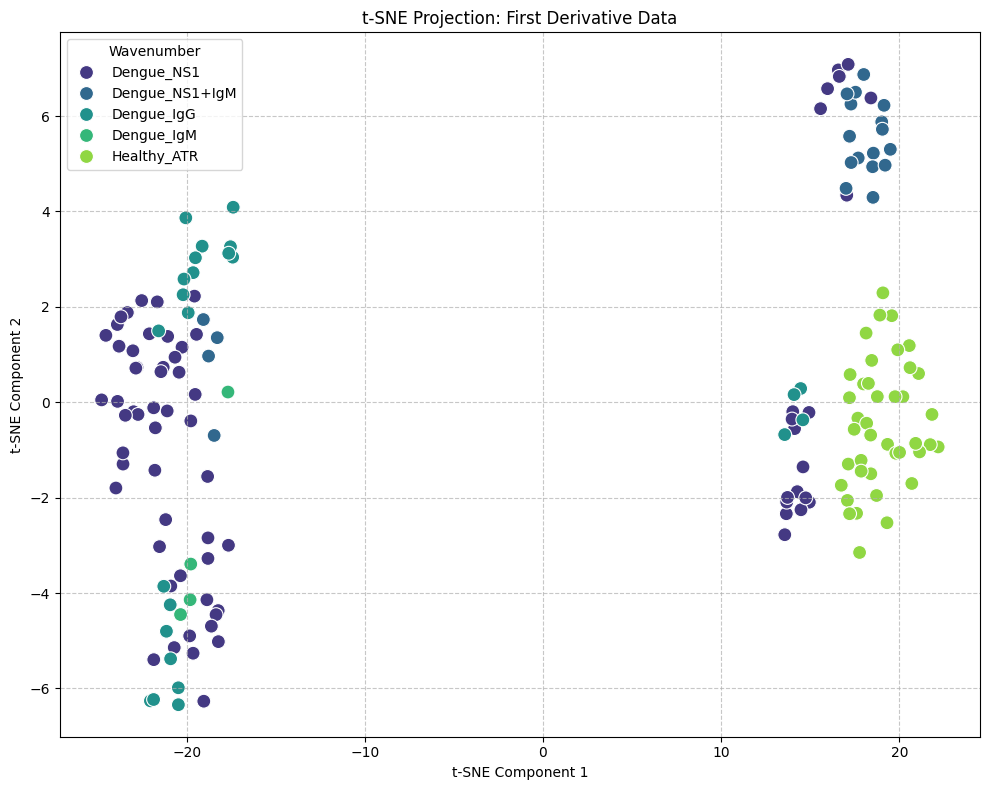

In [89]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Apply t-SNE to the derivative data (X_derivative_df)
tsne_deriv = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne_deriv = tsne_deriv.fit_transform(X_derivative_df)

# 2. Create a temporary DataFrame for plotting
plot_df_tsne_deriv = pd.DataFrame(data=X_tsne_deriv, columns=['TSNE1', 'TSNE2'])
plot_df_tsne_deriv['Wavenumber'] = y_derivative.values

# 3. Plot the t-SNE components
plt.figure(figsize=(10, 8))
sns.scatterplot(data=plot_df_tsne_deriv, x='TSNE1', y='TSNE2', hue='Wavenumber', palette='viridis', s=100)
plt.title('t-SNE Projection: First Derivative Data')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Side-by-Side t-SNE Comparison: Original vs. First Derivative
We will now plot both t-SNE projections together to evaluate the impact of the derivative transformation on class separation.

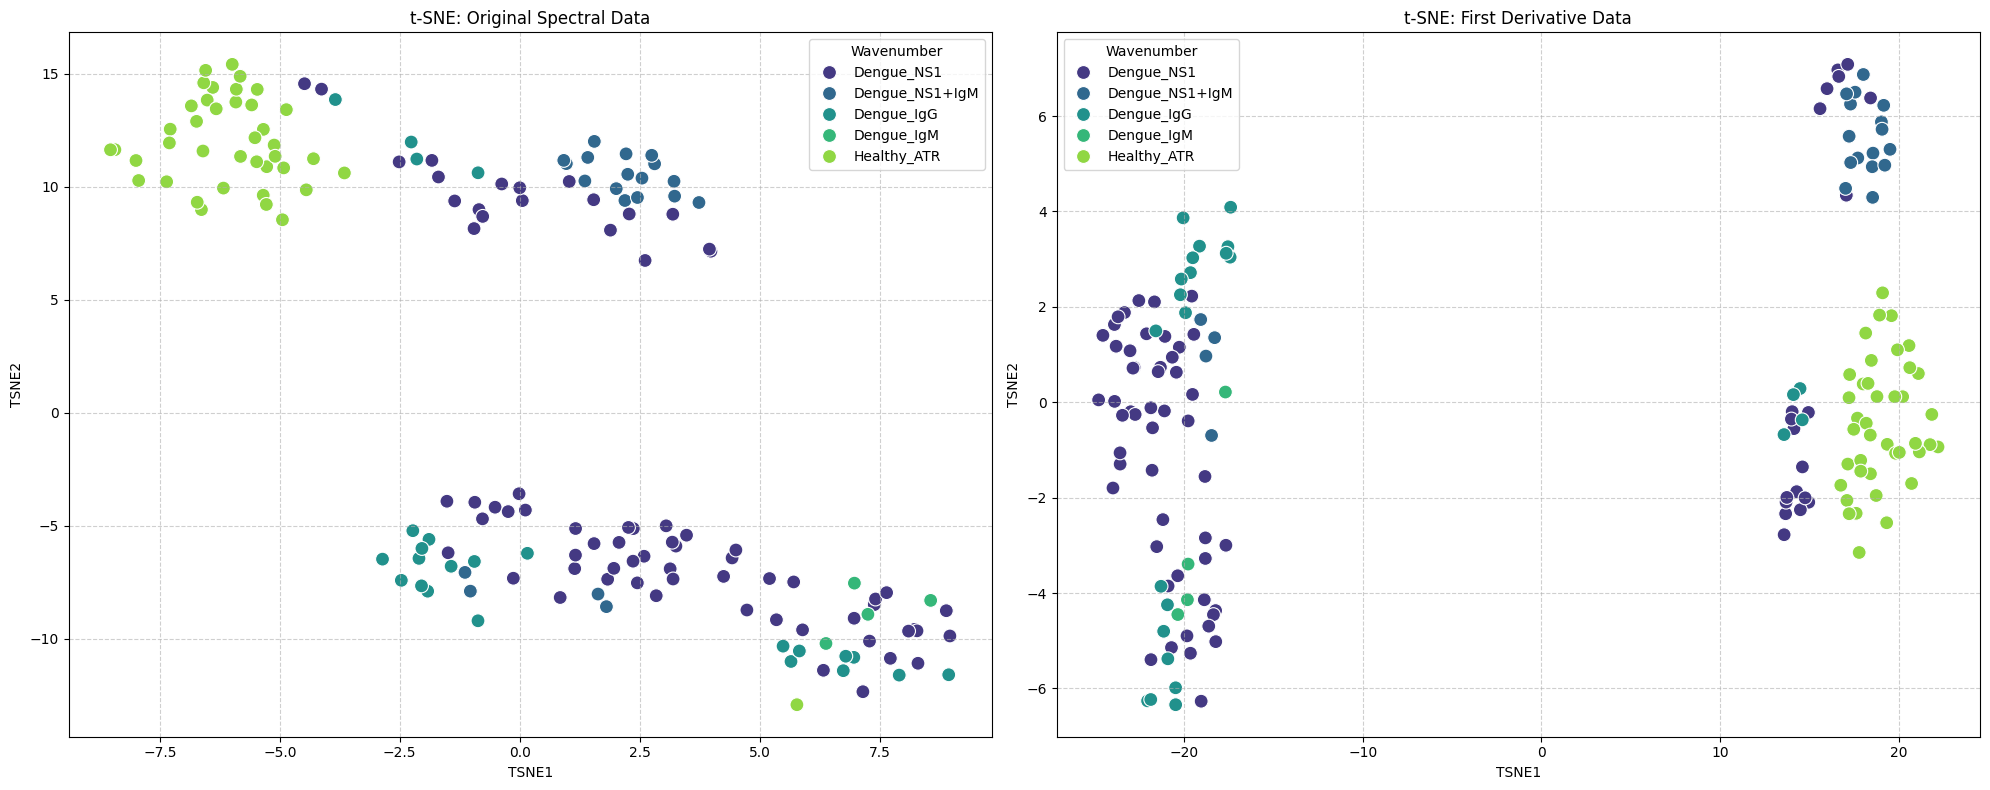

In [90]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Original Data t-SNE (using existing X_tsne and y)
sns.scatterplot(ax=ax1, data=plot_df_tsne, x='TSNE1', y='TSNE2', hue='Wavenumber', palette='viridis', s=100)
ax1.set_title('t-SNE: Original Spectral Data')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: First Derivative Data t-SNE (using existing X_tsne_deriv and y_derivative)
sns.scatterplot(ax=ax2, data=plot_df_tsne_deriv, x='TSNE1', y='TSNE2', hue='Wavenumber', palette='viridis', s=100)
ax2.set_title('t-SNE: First Derivative Data')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()